In [17]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import xgboost as xgb

# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

food_data_path = r"..\Data\synthetic_food_dataset_imbalanced.csv"
df = pd.read_csv(food_data_path)

# Drop duplicates and missing rows
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

# Handling Outliers in Numerical Data
def cap_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
        df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
        
    return df

num_cols = df.select_dtypes(include=['float64', 'int64']).columns
df = cap_outliers(df, num_cols)

# Handling Categorical Data
# Encoding 'Is_Vegan' and 'Is_Gluten_Free' columns  --> Binary Encoding
df['Is_Vegan'] = df['Is_Vegan'].astype(int)
df['Is_Gluten_Free'] = df['Is_Gluten_Free'].astype(int)

# One-Hot Encoding for 'Meal_Type' and 'Preparation_Method' columns -- Nominal Categorical Variables
df = pd.get_dummies(
    df,
    columns=['Meal_Type', 'Preparation_Method'],
    drop_first=True   # prevents dummy variable trap
)

X = df.drop('Food_Name', axis=1)
y = df['Food_Name']


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,      # important for imbalance
    random_state=42
)

label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

# Normalize numerical features
num_cols = [
    'Calories', 'Protein', 'Fat', 'Carbs', 'Sugar', 'Fiber',
    'Sodium', 'Cholesterol', 'Glycemic_Index',
    'Water_Content', 'Serving_Size'
]

scaler = StandardScaler()
X_train.loc[:, num_cols] = scaler.fit_transform(X_train[num_cols])
X_test.loc[:, num_cols] = scaler.transform(X_test[num_cols])



# Initialize PCA
pca = PCA(n_components=0.95, random_state=42)  # keep 95% variance

# Fit PCA only on training features
X_train_pca = pca.fit_transform(X_train)

# Transform test features using the same PCA
X_test_pca = pca.transform(X_test)

# Check how many components were selected
print("Original number of features:", X_train.shape[1])
print("Reduced number of features:", X_train_pca.shape[1])

# Initialize Model

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'XGBoost': xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

results = []

for name, model in models.items():
    # Train
    model.fit(X_train_pca, y_train)  # replace X_train_pca with X_train_selected if using feature selection
    
    # Predict
    y_pred = model.predict(X_test_pca)  # replace with selected features if used
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Store results
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-score': f1,
        'Confusion Matrix': cm
    })
    
# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Print Metrics
pd.set_option('display.max_columns', None)
print(results_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-score']])

# Print Confusion Matrices

for r in results:
    print(f"Confusion Matrix for {r['Model']}:\n{r['Confusion Matrix']}\n")



Original number of features: 19
Reduced number of features: 12


c:\Users\ajith\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:26:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


                 Model  Accuracy  Precision    Recall  F1-score
0  Logistic Regression  0.990083   0.990129  0.990083  0.990098
1        Decision Tree  0.982566   0.982622  0.982566  0.982578
2        Random Forest  0.989603   0.989639  0.989603  0.989608
3                  KNN  0.988164   0.988269  0.988164  0.988170
4                  SVM  0.991683   0.991764  0.991683  0.991706
5              XGBoost  0.990723   0.990769  0.990723  0.990728
6    Gradient Boosting  0.991043   0.991074  0.991043  0.991045
Confusion Matrix for Logistic Regression:
[[ 288    6    0    0    0    0    0    0    0    0]
 [   2  235    0    0    0    0    0    0    0    0]
 [   0    0  961    0    0    2   19    0    0    2]
 [   0    0    4  887    0    0    0    0    0    0]
 [   0    0    6    0  585    0    0    0    0    0]
 [   0    0    2    0    0  790    0    0    0    0]
 [   0    0   16    0    0    0 1164    0    0    0]
 [   1    0    0    0    0    0    0  196    0    0]
 [   0    0    0    0 

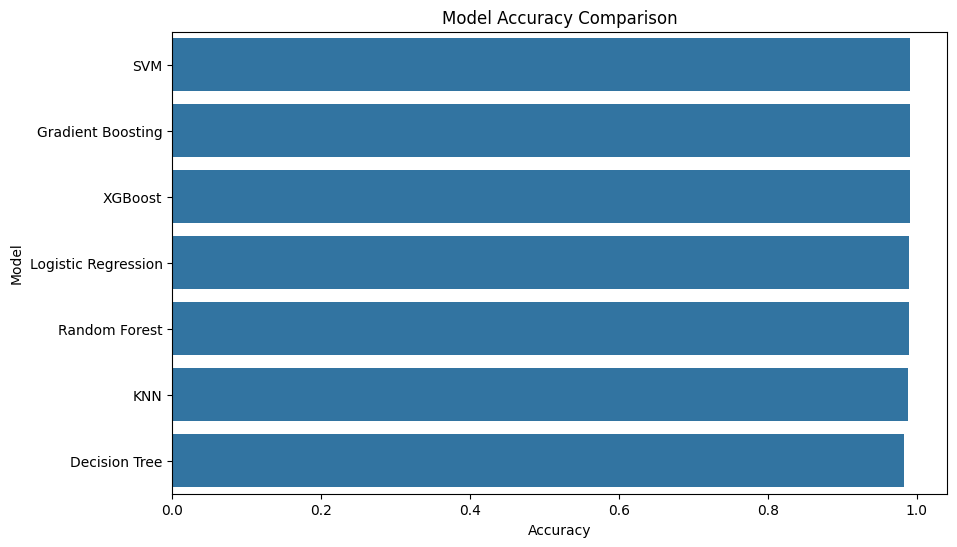

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(x='Accuracy', y='Model', data=results_df.sort_values(by='Accuracy', ascending=False))
plt.title("Model Accuracy Comparison")
plt.show()